In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
match_data = pd.read_csv("E:/IPL - Matches/IPL/IPL_Matches_2008_2022.csv")
ball_data = pd.read_csv("E:/IPL - Matches/IPL/IPL_Ball_by_Ball_2008_2022.csv")

In [23]:
match_data.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [20]:
ball_data.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [25]:
match_data.isnull().sum()

ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            4
WinningTeam          4
WonBy                0
Margin              18
method             931
Player_of_Match      4
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
dtype: int64

In [27]:
ball_data.isnull().sum()

ID                        0
innings                   0
overs                     0
ballnumber                0
batter                    0
bowler                    0
non-striker               0
extra_type           213905
batsman_run               0
extras_run                0
total_run                 0
non_boundary              0
isWicketDelivery          0
player_out           214803
kind                 214803
fielders_involved    217966
BattingTeam               0
dtype: int64

In [29]:
match_data.shape

(950, 20)

In [31]:
ball_data.shape

(225954, 17)

In [33]:
match_data.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [35]:
print('Matches played so far:',match_data.shape[0])
print('\n Cities played at:',match_data['City'].unique())
print('\n teams Participated:',match_data['Team1'].unique())

Matches played so far: 950

 Cities played at: ['Ahmedabad' 'Kolkata' 'Mumbai' 'Navi Mumbai' 'Pune' 'Dubai' 'Sharjah'
 'Abu Dhabi' 'Delhi' 'Chennai' nan 'Hyderabad' 'Visakhapatnam'
 'Chandigarh' 'Bengaluru' 'Jaipur' 'Indore' 'Bangalore' 'Kanpur' 'Rajkot'
 'Raipur' 'Ranchi' 'Cuttack' 'Dharamsala' 'Kochi' 'Nagpur' 'Johannesburg'
 'Centurion' 'Durban' 'Bloemfontein' 'Port Elizabeth' 'Kimberley'
 'East London' 'Cape Town']

 teams Participated: ['Rajasthan Royals' 'Royal Challengers Bangalore' 'Sunrisers Hyderabad'
 'Delhi Capitals' 'Chennai Super Kings' 'Gujarat Titans'
 'Lucknow Super Giants' 'Kolkata Knight Riders' 'Punjab Kings'
 'Mumbai Indians' 'Kings XI Punjab' 'Delhi Daredevils'
 'Rising Pune Supergiant' 'Gujarat Lions' 'Rising Pune Supergiants'
 'Pune Warriors' 'Deccan Chargers' 'Kochi Tuskers Kerala']


In [37]:
match_data['Season'] = pd.DatetimeIndex(match_data['Date']).year
match_data.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [39]:
match_per_season = match_data.groupby(['Season'])['ID'].count().reset_index().rename(columns={'ID':'matches'})
match_per_season

,Season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [101]:
print(match_data['Season'].unique())

[2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010 2009
 2008]


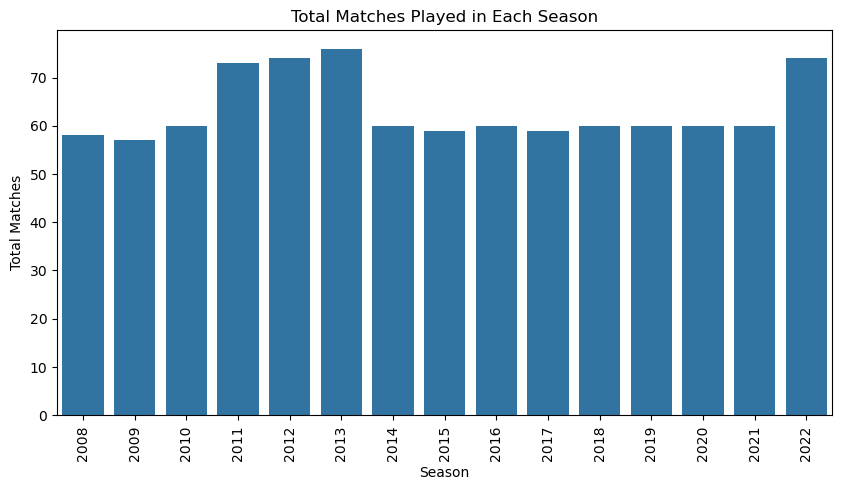

In [107]:
season_counts = match_data['Season'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.xticks(rotation=90)
plt.xlabel('Season')
plt.ylabel('Total Matches')
plt.title('Total Matches Played in Each Season')
plt.show()


In [43]:
season_data = match_data[['ID','Season']].merge(ball_data,left_on = 'ID',right_on = 'ID',how = 'left').drop('ID' , axis = 1)
season_data.head()

,Season,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,2022,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,2022,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,2022,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,2022,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,2022,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


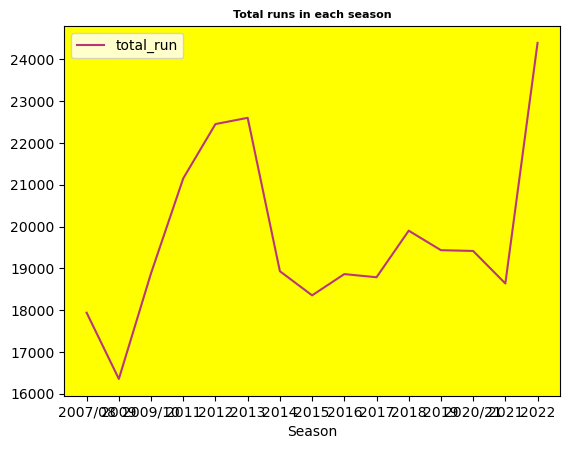

In [21]:
season = season_data.groupby(['Season'])['total_run'].sum().reset_index()
p = season.set_index('Season')
ax=plt.axes()
ax.set(facecolor = "yellow")
sns.lineplot(data=p ,palette= "magma")
plt.title('Total runs in each season',fontsize= 8 , fontweight= 'bold')
plt.show()

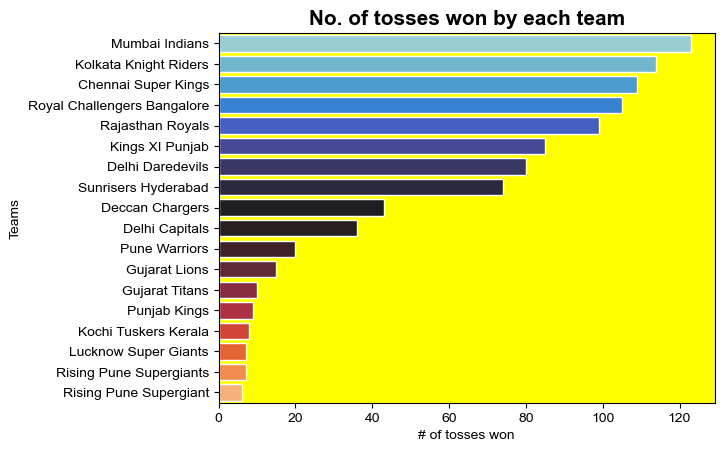

In [37]:
toss = match_data['TossWinner'].value_counts()
ax=plt.axes()
ax.set(facecolor = "yellow")
sns.set(rc= {'figure.figsize':(10,10)},style = 'darkgrid')
ax.set_title('No. of tosses won by each team',fontsize= 15,fontweight="bold")
sns.barplot(y= toss.index,x= toss, orient ='h',hue= toss.index ,palette="icefire",saturation = 1)
plt.xlabel('# of tosses won')
plt.ylabel('Teams')
plt.show()


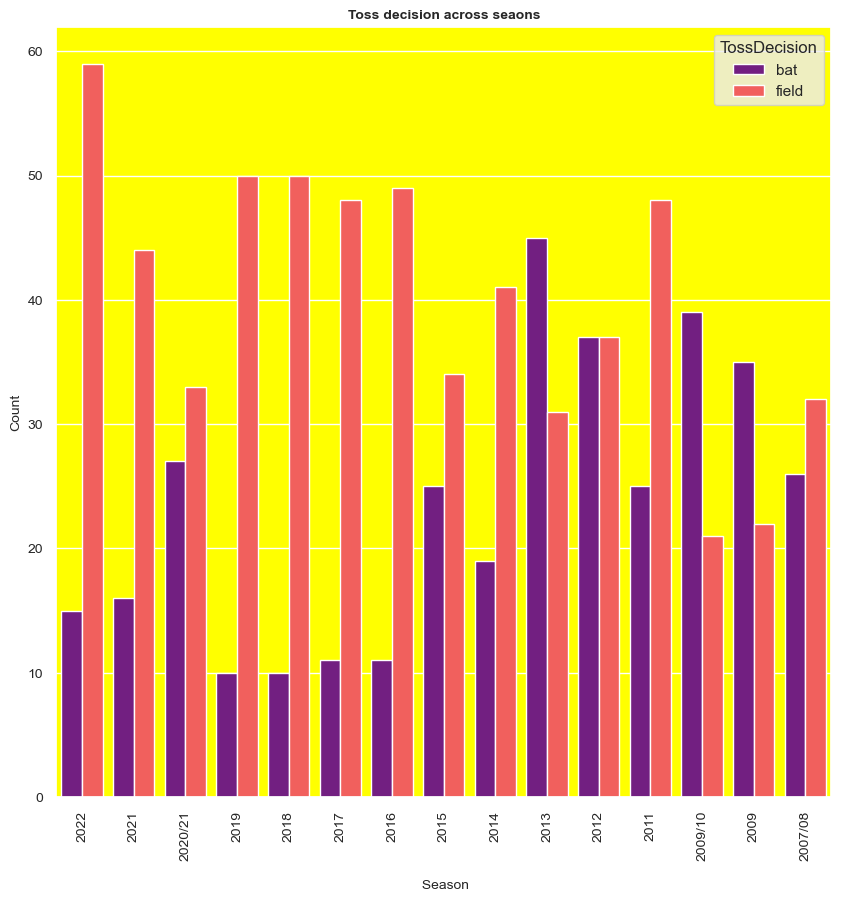

In [39]:
ax=plt.axes()
ax.set(facecolor= "yellow")
sns.countplot(x='Season',hue='TossDecision', data=match_data,palette='magma',saturation=1)
plt.xticks(rotation=90,fontsize= 10)
plt.yticks( fontsize= 10)
plt.xlabel('\n Season',fontsize= 10)
plt.ylabel('Count',fontsize= 10)
plt.title('Toss decision across seaons',fontsize= 10,fontweight="bold")
plt.show()


In [127]:
match_data['WonBy'].value_counts()

WonBy
Wickets      509
Runs         423
SuperOver     14
NoResults      4
Name: count, dtype: int64

In [135]:
match_data.Venue[match_data.WonBy!='runs'].mode()

0    Eden Gardens
Name: Venue, dtype: object

In [33]:
match_data.Venue[match_data.WonBy!='wickets'].mode()

0    Eden Gardens
Name: Venue, dtype: object

In [37]:
match_data.Venue[match_data.TossWinner== 'Mumbai Indians'][match_data.TossWinner=='Mumbai Indians'].mode()

0    Wankhede Stadium
Name: Venue, dtype: object

In [42]:
match_data.WinningTeam[match_data.WonBy!='runs'].mode()

0    Mumbai Indians
Name: WinningTeam, dtype: object

In [44]:
match_data.WinningTeam[match_data.WonBy!='wickets'].mode()

0    Mumbai Indians
Name: WinningTeam, dtype: object

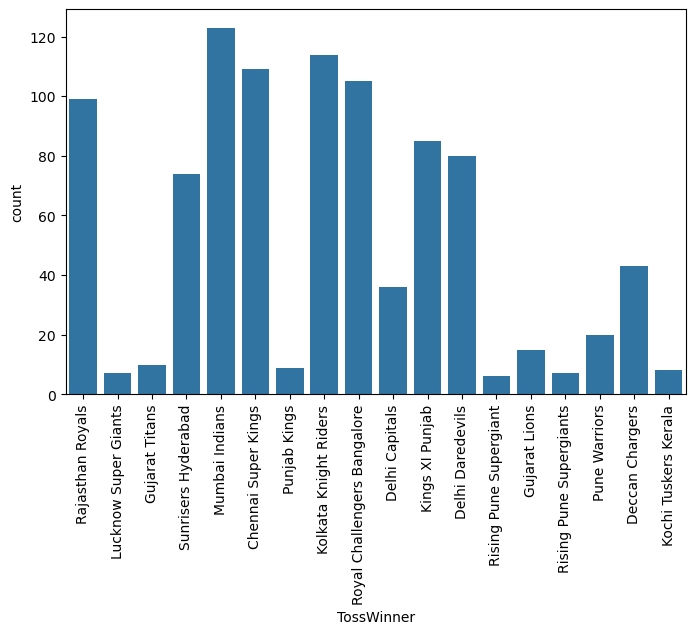

In [71]:
plt.figure(figsize= (8,5))
sns.countplot(x=match_data['TossWinner'])
plt.xticks(rotation= 90)
plt.show()

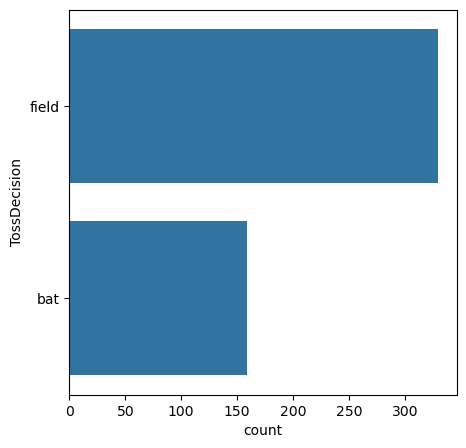

In [62]:
plt.figure(figsize= (5,5))
sns.countplot(match_data.TossDecision[match_data.TossWinner==match_data.WinningTeam])
plt.show()

In [73]:
player = (ball_data['batter']=='YBK Jaiswal')
dataframe_jaiswal= ball_data[player]
dataframe_jaiswal.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
5,1312200,1,0,6,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [89]:
player = (ball_data['batter']=='YBK Jaiswal')
dataframe_jaiswal=ball_data[player]
dataframe_jaiswal.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
5,1312200,1,0,6,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


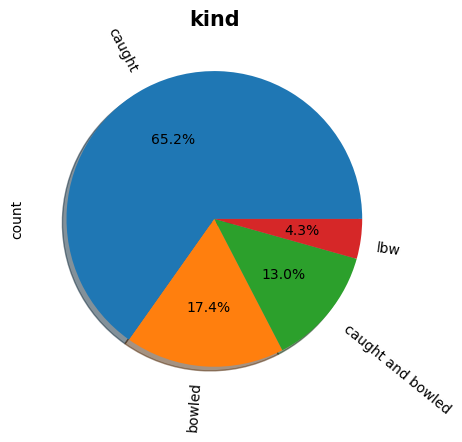

In [95]:
dataframe_jaiswal['kind'].value_counts().plot.pie(autopct='%1.1f%%',shadow=True,rotatelabels=True)
plt.title("kind",fontweight="bold",fontsize=15)
plt.show()

In [79]:
print(dataframe_jaiswal.head())

        ID  innings  overs  ballnumber       batter          bowler  \
0  1312200        1      0           1  YBK Jaiswal  Mohammed Shami   
1  1312200        1      0           2  YBK Jaiswal  Mohammed Shami   
3  1312200        1      0           4  YBK Jaiswal  Mohammed Shami   
4  1312200        1      0           5  YBK Jaiswal  Mohammed Shami   
5  1312200        1      0           6  YBK Jaiswal  Mohammed Shami   

  non-striker extra_type  batsman_run  extras_run  total_run  non_boundary  \
0  JC Buttler        NaN            0           0          0             0   
1  JC Buttler    legbyes            0           1          1             0   
3  JC Buttler        NaN            0           0          0             0   
4  JC Buttler        NaN            0           0          0             0   
5  JC Buttler        NaN            0           0          0             0   

   isWicketDelivery player_out kind fielders_involved       BattingTeam  
0                 0        NaN

In [81]:
def count(dataframe_jaiswal,runs):
    return len(dataframe_jaiswal[dataframe_jaiswal['batsman_run']==runs])*runs

In [83]:
print("Runs scored from 1's:",count(dataframe_jaiswal,1))
print("Runs scored from 2's:",count(dataframe_jaiswal,2))
print("Runs scored from 3's:",count(dataframe_jaiswal,3))
print("Runs scored from 4's:",count(dataframe_jaiswal,4))
print("Runs scored from 6's:",count(dataframe_jaiswal,6))

Runs scored from 1's: 133
Runs scored from 2's: 28
Runs scored from 3's: 6
Runs scored from 4's: 248
Runs scored from 6's: 132


In [109]:
match_data[match_data['Margin']==match_data['Margin'].max()]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
329,1082635,Delhi,2017-05-06,2017,45,Delhi Daredevils,Mumbai Indians,Feroz Shah Kotla,Delhi Daredevils,field,N,Mumbai Indians,Runs,146.0,NaN,LMP Simmons,"['SV Samson', 'KK Nair', 'SS Iyer', 'RR Pant',...","['LMP Simmons', 'PA Patel', 'KA Pollard', 'RG ...",Nitin Menon,CK Nandan


In [97]:
runs = ball_data.groupby(['batter'])['batsman_run'].sum().reset_index()
runs.columns = ['Batter','runs']
y = runs.sort_values(by='runs',ascending = False).head(10).reset_index().drop('index', axis=1)
y

,Batter,runs
0,V Kohli,6634
1,S Dhawan,6244
2,DA Warner,5883
3,RG Sharma,5881
4,SK Raina,5536
5,AB de Villiers,5181
6,CH Gayle,4997
7,MS Dhoni,4978
8,RV Uthappa,4954
9,KD Karthik,4377


Text(0.5, 1.0, 'Highest MOM award winner')

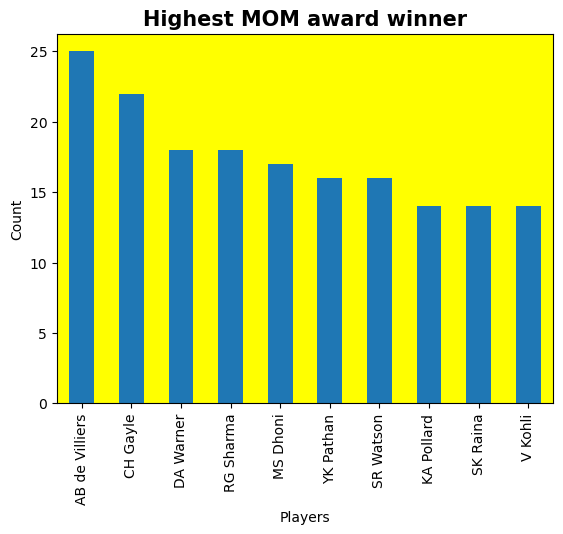

In [11]:
ax=plt.axes()
ax.set(facecolor = "yellow")
match_data.Player_of_Match.value_counts()[:10].plot(kind='bar')
plt.xlabel('Players')
plt.ylabel("Count")
plt.title("Highest MOM award winner",fontsize=15,fontweight="bold")